In [8]:
import pandas as pd
from matplotlib import pyplot as plt

fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/1. p(z | X)/2024-12-11_14-28-54_simple_z_reg_vit/results.csv"
df = pd.read_csv(fp)
df.head()

,global_train_step,global_val_step,epoch,train_loss,val_loss,z
0,0.0,NaN,0,0.415674,NaN,0.084697
1,1.0,NaN,0,0.386359,NaN,0.133266
2,2.0,NaN,0,0.411431,NaN,0.009413
3,3.0,NaN,0,0.420301,NaN,0.169122
4,4.0,NaN,0,0.405027,NaN,0.021514


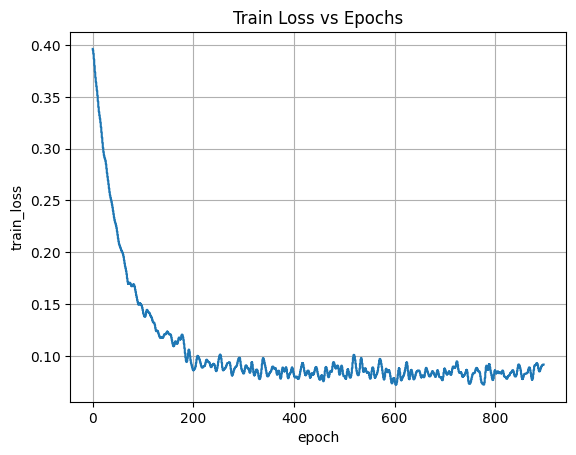

In [9]:
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter1d

SIGMA = 30

_df = df[df["global_train_step"].notna()]
train_steps = _df["epoch"]
train_losses = _df["train_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

# plt.plot(train_steps, train_losses)
plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("train_loss")
plt.title("Train Loss vs Epochs")
plt.grid()
plt.show()

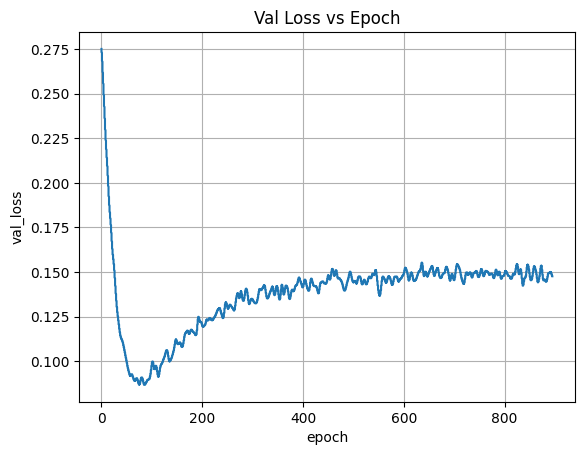

In [10]:
# plot val_loss vs. global_val_step
_df = df[df["global_val_step"].notna()]

val_steps = _df["epoch"]
val_losses = _df["val_loss"]
val_losses_smoothed = gaussian_filter1d(val_losses, sigma=SIGMA)

# plt.plot(val_steps, val_losses)
plt.plot(val_steps, val_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.title("Val Loss vs Epoch")
plt.grid()
plt.show()

In [11]:
import numpy as np

f"{(np.mean(train_losses[-500: ]) * 100):.5f}%", f"{(np.mean(val_losses[-500: ])):.5f}%"

('8.77051%', '0.14743%')

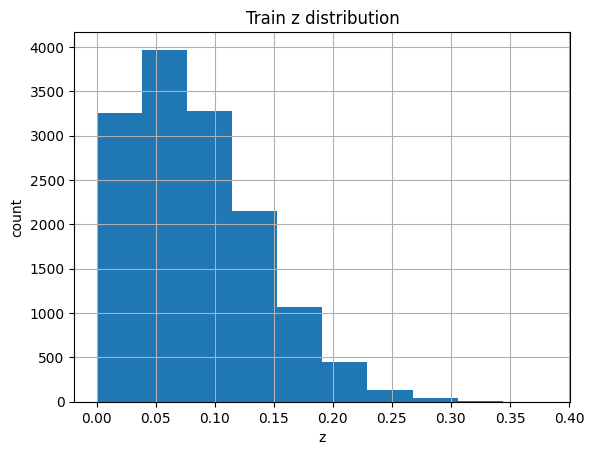

mean: 0.0840719328050002
std: 0.05511993923119285


In [12]:
_df = df[~df['global_val_step'].notnull()]
zs = _df["z"]

# plot a histogram of z
plt.hist(zs)
plt.xlabel("z")
plt.ylabel("count")
plt.title("Train z distribution")
plt.grid()
plt.show()

# show on figure mean and std of zs
print(f"mean: {zs.mean()}")
print(f"std: {zs.std()}")

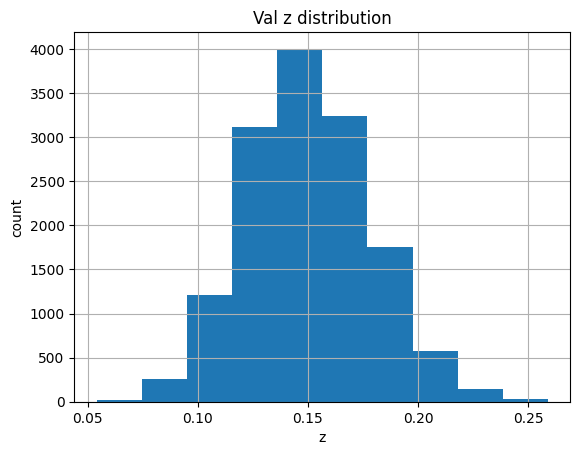

mean: 0.15037181103616604
std: 0.028258045897354648


In [13]:
_df = df[df['global_val_step'].notnull()]
zs = _df["z"]

# plot a histogram of z
plt.hist(zs)
plt.xlabel("z")
plt.ylabel("count")
plt.title("Val z distribution")
plt.grid()
plt.show()

# show on figure mean and std of zs
print(f"mean: {zs.mean()}")
print(f"std: {zs.std()}")

In [14]:
import math

# Given mean and standard deviation
mean = zs.mean()
std_dev = zs.std()

# Calculate MAE using the formula for a normal distribution
mae = std_dev * math.sqrt(2 / math.pi)

print(f"MAE of always predicting the mean: {mae * 100:.5f}%")

MAE of always predicting the mean: 2.25467%
